In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
ftsz = 12
plt.rcParams["font.family"] = "Serif"
plt.rc('xtick', labelsize=ftsz)
plt.rc('ytick', labelsize=ftsz)

# Argon simulation in the canonical ensemble

<p align="center">
  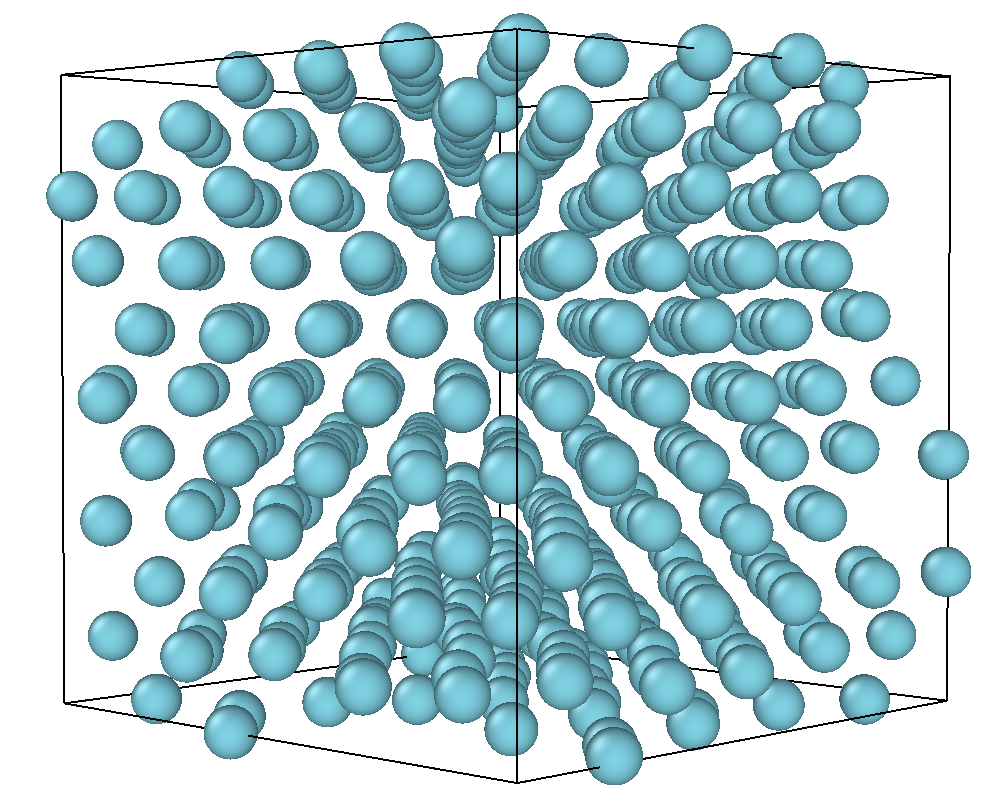
</p>

In [ ]:
<p align="center">
  <img src="https://raw.githubusercontent.com/Luca-R27/PhDcourse_2026_CompMatMod/blob/main/MD/Ar_NVT_50K.png" width="50%">
</p>

## Energy minimisation:

For the whole box (500 atoms):

$E$ = $U$ = -42.854  eV

$V$ = 18247.7 Å³

Corresponding to cohesive energy and lattice constant:

$E_{coh}$ = 85 meV

$a$ = 5.265 Å

## NVT run

Run at 35 K, 50 K and 65 K. Expect, after equilibration, fluctuating quantities about steady values.



In [11]:
# NOTE: if using colab, uncomment both lines and run as many times as files to upload. 
# Uploaded copy will keep its filename and can be seen by np.loadtxt() later on.

#from google.colab import files
#uploaded = files.upload()  # Opens a file picker dialog

In [12]:
# Load the data from LAMMPS. Columns: time	pe	ke	etotal	vol	press	temp

data_run_35K = np.loadtxt('Ar_nvt_35K.dat')[1000:, :] # skip the equilibration step
data_run_50K = np.loadtxt('Ar_nvt_50K.dat')[1000:, :]    # skip the equilibration step
data_run_65K = np.loadtxt('Ar_nvt_65K.dat')[1000:, :]  # skip the equilibration step

N = 500  # atoms
T = np.array([35, 50, 65]) # temperatures [K]

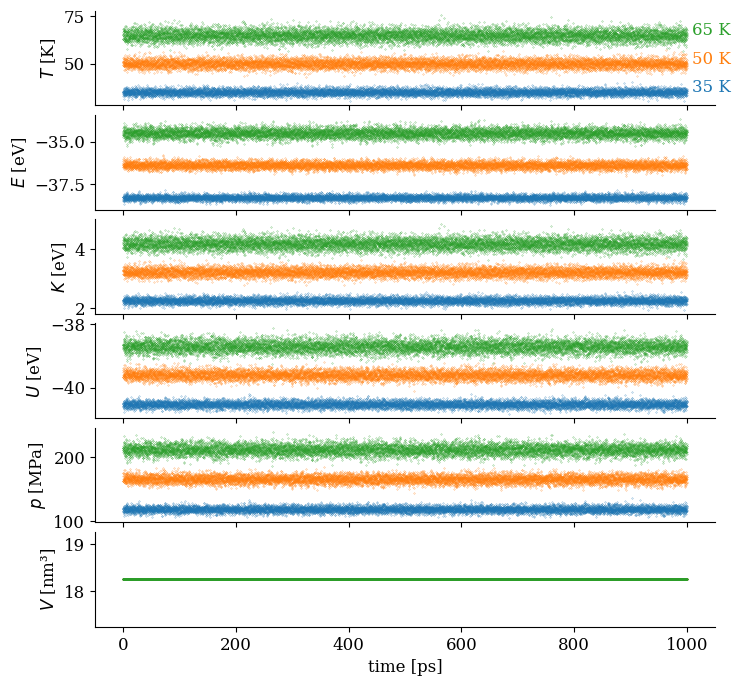

In [13]:
# Plot the time evolution

fig, ax = plt.subplots(6, 1, figsize=(8, 8), sharex=True, gridspec_kw={"hspace": 0.1})

# Each entry: (column index in data, scale_factor, ylabel)
channels = [
    (6, 1,          r"$T$ [K]"),
    (3, 1,  r"$E$ [eV]"),
    (2, 1,  r"$K$ [eV]"),
    (1, 1,  r"$U$ [eV]"),
    (5, 0.101325,   r"$p$ [MPa]"),
    (4, 1e-3,       r"$V$ [nm³]"),
]

for i, data in enumerate([data_run_35K, data_run_50K, data_run_65K]):
    t = (data[:, 0] - data[0, 0])
    for axis, (col, scale, label) in zip(ax, channels):
        axis.plot(t, scale * data[:, col], 'o', markersize=0.2, color=f'C{i}')
    
    ax[0].text(1010, T[i], f"{T[i]} K", color=f'C{i}', fontsize=ftsz) # legend

for axis, (_, _, label) in zip(ax, channels):
    axis.set_ylabel(label, fontsize=ftsz)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
ax[5].set_xlabel("time [ps]", fontsize=ftsz)

plt.show()


# Estimate heat capacity in the canonical ensemble

We will use the fact that given the total energy $E$, sum of potential and kinetic energy:

$$ \langle E^2\rangle - \langle E\rangle^2 = \sigma_E = k_BT^2C_V $$

to estimate $C_V$ in the classical limit of the Dulong-Petit law.

This will give us the heat capacity $C_V$ of the simulation box. To obtain the molar specific heat capacity $c_V$, we scale using the number of atoms in the simulation $N$ with respect to Avogadro's number $N_A$:
$$ c_v = \frac{\sigma_E}{k_BT^2}\frac{N_A}{N} $$


NOTE: there is no quantum behaviour in classical MD! We shall not see any temperature dependence in $c_V$, but expect a constant value approaching $c_V \approx 3R$=24.9 J/mol/K.

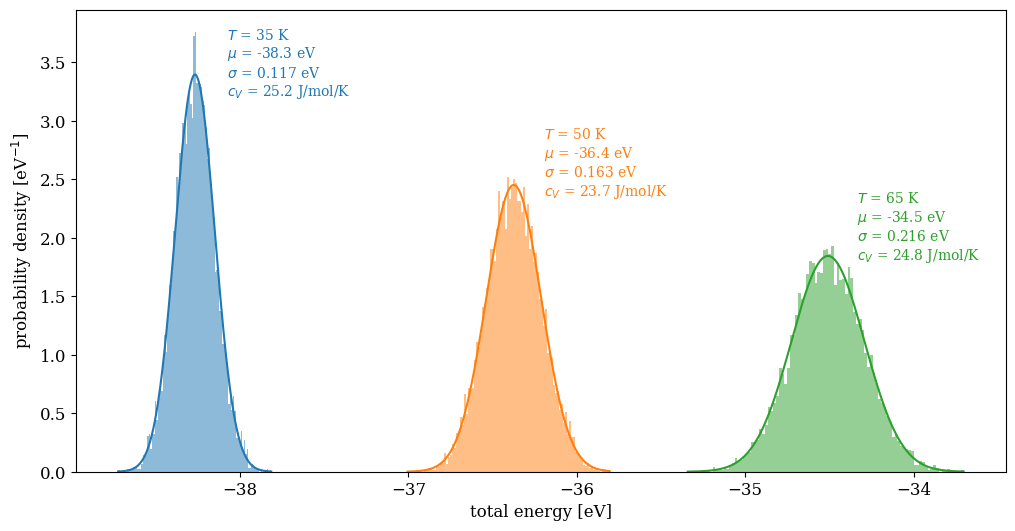

In [10]:
plt.figure(figsize=(12, 6))
for i, data in enumerate([data_run_35K, data_run_50K, data_run_65K]):
    E = data[:, 3] # eV
    x = np.linspace(E.min(), E.max(), 300)

    # plot the histogram of the total energy
    plt.hist(E, bins=100, density=True, color=f'C{i}', alpha=0.5)
    # fit a Gaussian and plot it alongside
    mu, sigma = scipy.stats.norm.fit(E)
    pdf = scipy.stats.norm.pdf(x, mu, sigma)
    plt.plot(x, pdf)
    # estimation of 
    c_V = sigma**2/(8.6173e-5*T[i]**2)*1.602e-19*6.022e23/N

    plt.text(mu*0.995, pdf.max()*0.9, f"$T$ = {T[i]:.3g} K\n$\mu$ = {mu:.3g} eV\n$\sigma$ = {sigma:.3g} eV\n$c_V$ = {c_V:.3g} J/mol/K\n", color=f'C{i}')

plt.xlabel('total energy [eV]', fontsize=ftsz)
plt.ylabel(r'probability density [eV$^{-1}$]', fontsize=ftsz)
plt.show()

# SiC
## Canonical ensemble again

Run a tetrahedral 3C-SiC for a few timesteps at constant temperature in a canonical ensemble and study the distributions of velocities, positions, energies etc.

In [23]:
# Values for the example files

N_atoms = 64000
T_nvt = 1550 # K NVT is set to. This is half of the melting point.
a = 4.321 # lattice parameter with this Tersoff potential
N_cells = 20

# First open the file containing velocities and positions of a single Si and a single C atom
data = np.loadtxt('SiC_pair_1550K.dat')
v_Si = np.sqrt(data[:, 3]**2+data[:, 4]**2+data[:, 5]**2)
v_C = np.sqrt(data[:, 10]**2+data[:, 11]**2+data[:, 12]**2)

T = data[:, 14]
E = data[:, 15]

# colours for plotting
Si_colors = ['#FFD700', '#C0A020', '#8B7536']
C_colors  = ['#111111', '#555555', '#999999']

# check
print(f"The mean temperature was {np.mean(T):.6g} while T was set to {T_nvt:.6g} K.")


The mean temperature was 1548.82 while T was set to 1550 K.


### Trajectory of a single Si and of a single C atom

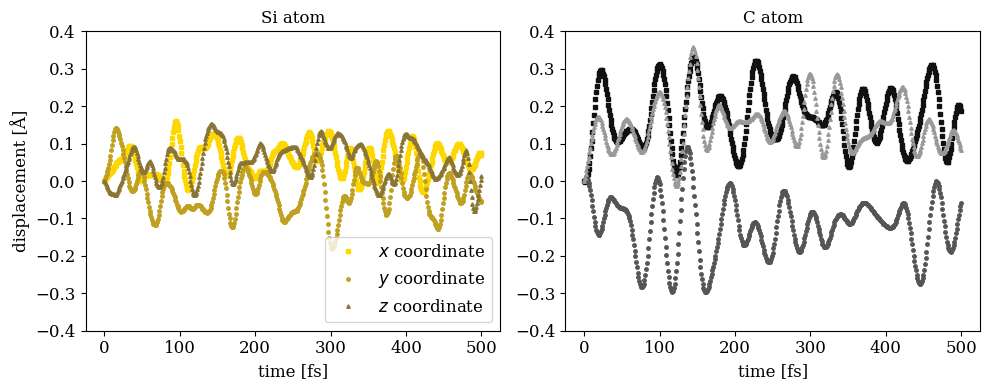

In [36]:
# Simply plot the spatial coordinates of the atoms vibrating about the bottom of the potential well

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = np.array([r"$x$ coordinate", r"$y$ coordinate", r"$z$ coordinate"])

for cols, ax, atom_label, atom_colors, mrk in zip([(0,1,2), (7,8,9)], axes, ["Si atom", "C atom"], [Si_colors, C_colors], [['s','o','^'], ['s','o','^']]):
    for j, col in enumerate(cols):
        ax.plot(data[:, col] - data[0, col], mrk[j], label=labels[j], markersize=2.5, color=atom_colors[j])
    ax.set_xlabel('time [fs]', fontsize=ftsz)
    ax.set_ylim(-0.4, 0.4)
    ax.set_title(atom_label)

axes[0].set_ylabel('displacement [Å]', fontsize=ftsz)
axes[0].legend(fontsize=ftsz, loc="lower right")
plt.tight_layout()
plt.show()

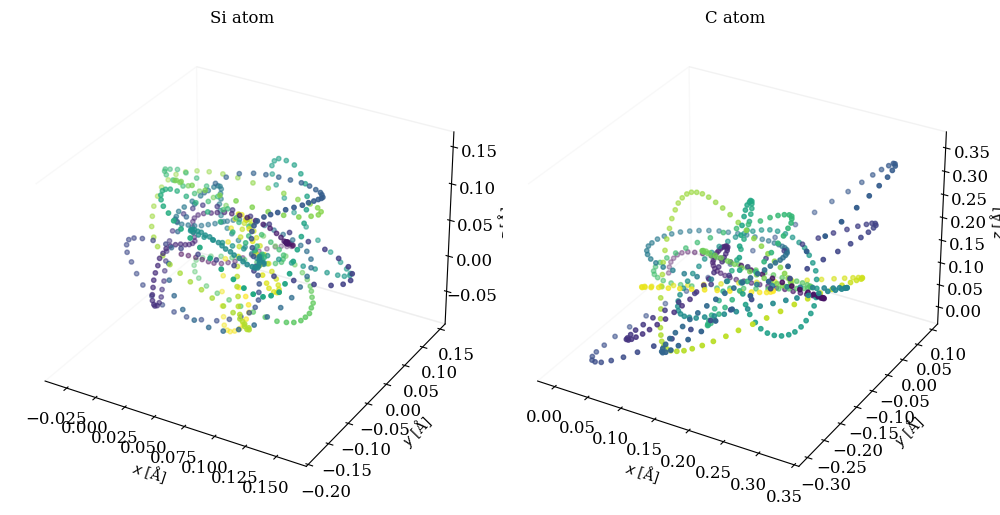

In [39]:
# same but in 3D, colouring by increasing time

fig = plt.figure(figsize=(10, 5))
for idx, (cols, title) in enumerate(zip([(0,1,2), (7,8,9)], ["Si atom", "C atom"])):
    ax = fig.add_subplot(1, 2, idx+1, projection='3d')
    xyz = data[:, cols] - data[0, cols]
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], c=range(len(data)), cmap='viridis', s=10)

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(False)

    ax.set_xlabel(r'$x$ [Å]')
    ax.set_ylabel(r'$y$ [Å]')
    ax.set_zlabel(r'$z$ [Å]')
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Collective behaviour of the ensemble of atoms

First we need some helper functions:
- To extract the data for a single snapshot from the dump file
- Fitting function for a single component of velocity: Gaussian

$$f(v_i) = \sqrt{\frac{m}{2\pi k_B T}} \exp\left(-\frac{m v_i^2}{2k_B T}\right)$$

- Fitting function for the kinetic energy: same as Maxwell-Boltzmann

$$f(K) = \frac{2}{\sqrt{\pi}}\left(\frac{1}{k_B T}\right)^{3/2} \sqrt{K} \exp\left(-\frac{K}{k_B T}\right)$$

- Coordinates oscillate about periodically repeating lattice sites. To aggregate statistics, we need to remove the periodicity and bring all to a common displacement from the equilibrium sites.

In [40]:
def get_frame(file, frame, N_atoms):
    # read the dump file with N_atoms and extract one frame
    data = np.loadtxt(file, skiprows=(frame*(N_atoms+9)+9), max_rows=N_atoms)
    return data

In [41]:
def v_fit(v, m, T):
    # return the Gaussian fit that applies to individual components of velocity in the Maxwell-Boltzmann distribution
    # v in A/ps, m in a.m.u., T in K
    kB = 8.617e-5
    conv_factor = 1.602e-19/1.66e-27/1e4 # eV -> J, J -> a.m.u.*A^2/ps^2
    std = np.sqrt(kB*T*conv_factor/m)
    return 1/std/np.sqrt(2*np.pi)*np.exp(-(v/std)**2/2)

In [42]:
def K_fit(K, T):
    # Analytical expression for the kinetic energy. Same as total energy for a M-B system where U = 0 --> E = K.
    # K in eV, m in a.m.u., T in K
    kB = 8.617e-5
    return 2*np.sqrt(K/np.pi)/(kB*T)**(3/2)*np.exp(-K/(kB*T))

In [44]:
def shift_coords(x, a, N_cells):
    # find the closest ideal lattice position and shift coordinates to aggregate all deviations from the ideal.
    # this is only to collect all displacements into a single histogram rather than many at all lattice sites
    # It exploits that both Si and C are in an fcc lattice.
    sites = np.arange(0, 2*N_cells + 1) * (a / 2)
    diffs = x[:, None] - sites[None, :]
    idx   = np.argmin(np.abs(diffs), axis=1)
    return diffs[np.arange(len(x)), idx]

In [67]:
# Load the i-th snapshots of the dump file and extract: energies, coordinates and velocities separated by atom type 

data = get_frame('SiC_1550K.dump', 6, N_atoms)
# column 1 has the atom type, which we'll use to separate data into Si (type 1) and C (type 2)
# columns 3 to 5 have coordinates, columns 6 to 8 are velocities, 9 is potential energy, 10 is hydrostatic atomic stress

# Positions and velocities
x_Si = data[data[:, 1]==1,2]
x_C = data[data[:, 1]==2,2]
y_Si = data[data[:, 1]==1,3]
y_C = data[data[:, 1]==2,3]
z_Si = data[data[:, 1]==1,4]
z_C = data[data[:, 1]==2,4]
v_x_Si = data[data[:, 1]==1,5]
v_x_C = data[data[:, 1]==2,5]
v_y_Si = data[data[:, 1]==1,6]
v_y_C = data[data[:, 1]==2,6]
v_z_Si = data[data[:, 1]==1,7]
v_z_C = data[data[:, 1]==2,7]

# Energies
v = np.sqrt(data[:, 5]**2+data[:, 6]**2+data[:, 7]**2)
K = 1/2*1.66e-23/1.602e-19*np.where(data[:, 1] == 1, 28, 12)*v**2
K_Si = K[data[:, 1]==1]
K_C = K[data[:, 1]==2]
U = data[:, 8]
U_Si = U[data[:, 1]==1]
U_C = U[data[:, 1]==2]
E_Si = K_Si + U_Si
E_C = K_C + U_C


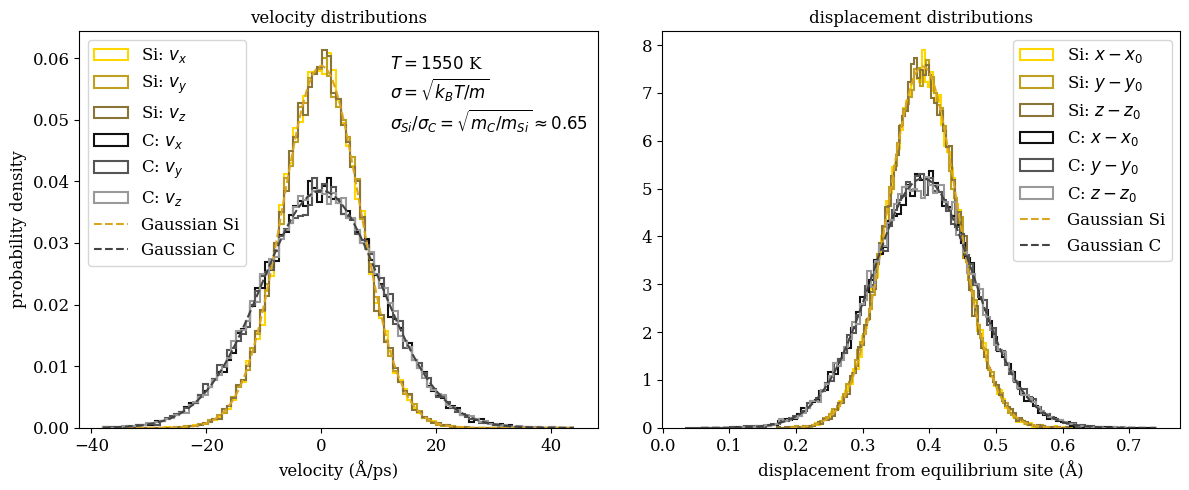

In [85]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

Si_colors = ['#FFD700', '#C0A020', '#8B7536']
C_colors  = ['#111111', '#555555', '#999999']

labels_Si = ['Si: $v_x$', 'Si: $v_y$', 'Si: $v_z$']
labels_C  = ['C: $v_x$',  'C: $v_y$',  'C: $v_z$']

disp_labels_Si = ['Si: $x-x_0$', 'Si: $y-y_0$', 'Si: $z-z_0$']
disp_labels_C  = ['C: $x-x_0$',  'C: $y-y_0$',  'C: $z-z_0$']

# velocity histograms 
bins_v = np.linspace(np.min(v_x_C), np.max(v_x_C), num=100)

for v, color, label in zip([v_x_Si, v_y_Si, v_z_Si], Si_colors, labels_Si):
    ax1.hist(v, bins=bins_v, histtype='step', density=True, color=color, label=label, linewidth=1.5)

for v, color, label in zip([v_x_C, v_y_C, v_z_C], C_colors, labels_C):
    ax1.hist(v, bins=bins_v, histtype='step', density=True, color=color, label=label, linewidth=1.5)

ax1.plot(bins_v, v_fit(bins_v, 28, T_nvt), color='#DAA520', linestyle='--', label='Gaussian Si', linewidth=1.5)
ax1.plot(bins_v, v_fit(bins_v, 12, T_nvt), color='#444444', linestyle='--', label='Gaussian C',  linewidth=1.5)

ax1.set_xlabel('velocity (Å/ps)', fontsize=ftsz)
ax1.set_ylabel('probability density', fontsize=ftsz)
ax1.set_title('velocity distributions', fontsize=ftsz)
ax1.legend(fontsize=ftsz)

# displacement histograms
sx   = shift_coords(x_Si,      a, N_cells)
sy   = shift_coords(y_Si,      a, N_cells)
sz   = shift_coords(z_Si,      a, N_cells)
cx   = shift_coords(x_C - a/4, a, N_cells)
cy   = shift_coords(y_C - a/4, a, N_cells)
cz   = shift_coords(z_C - a/4, a, N_cells)

for u, color, label in zip([sx, sy, sz], Si_colors, disp_labels_Si):
    ax2.hist(u, bins=100, histtype='step', density=True, color=color, label=label, linewidth=1.5)

for u, color, label in zip([cx, cy, cz], C_colors, disp_labels_C):
    ax2.hist(u, bins=100, histtype='step', density=True, color=color, label=label, linewidth=1.5)

# Gaussian fits — one per species, using x-component as representative
for u0, color, label in zip([sx, cx], ['#DAA520', '#444444'],['Gaussian Si', 'Gaussian C']):
    x_fit = np.linspace(u0.min(), u0.max(), 300)
    mu, sigma = scipy.stats.norm.fit(u0)
    ax2.plot(x_fit, scipy.stats.norm.pdf(x_fit, mu, sigma), color=color, linestyle='--', linewidth=1.5, label=label)

ax2.set_xlabel('displacement from equilibrium site (Å)', fontsize=ftsz)
ax2.set_title('displacement distributions', fontsize=ftsz)
ax2.legend(fontsize=ftsz)

ax1.text(.6, .75, f"$T={T_nvt}$ K"+f"\n"+r"$\sigma=\sqrt{k_BT/m}$"+f"\n"+r"$\sigma_{Si}/\sigma_{C}=\sqrt{m_{C}/m_{Si}}\approx0.65$", transform=ax1.transAxes, fontsize=ftsz)

plt.tight_layout()
plt.show()

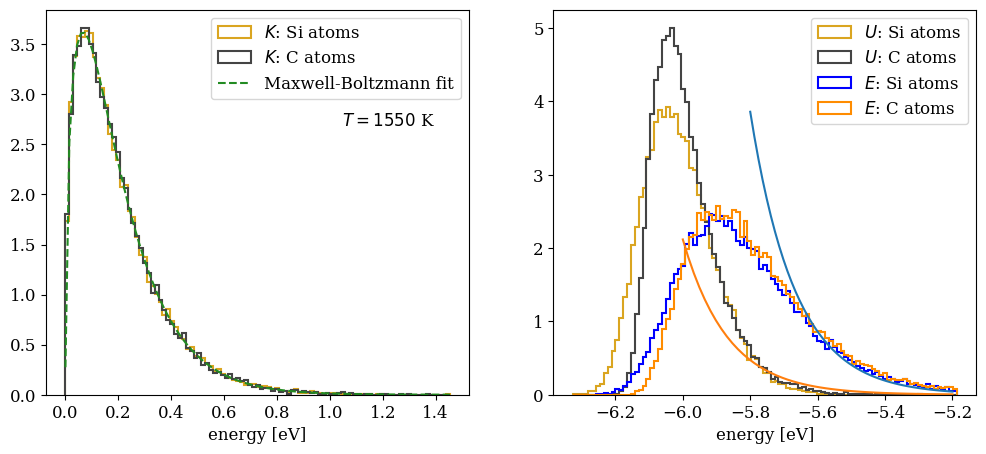

In [124]:
K_bins = np.linspace(np.min(K), np.max(K), num=100)
U_bins = np.linspace(np.min(U), np.max(U), num=100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(K_Si, bins=K_bins, histtype='step', density=True, color='#DAA520', label=r"$K$: Si atoms", linewidth=1.5)
ax1.hist(K_C, bins=K_bins, histtype='step', density=True, color='#444444', label=r"$K$: C atoms", linewidth=1.5)
ax1.plot(K_bins, K_fit(K_bins, T_nvt), linestyle='--', label='Maxwell-Boltzmann fit', linewidth=1.5, color="forestgreen")
ax1.legend(fontsize=ftsz)
ax1.set_xlabel('energy [eV]', fontsize=ftsz)
ax1.text(.7, .7, f"$T={T_nvt}$ K", transform=ax1.transAxes, fontsize=ftsz)

ax2.hist(U_Si, bins=U_bins, histtype='step', density=True, color='#DAA520', label=r"$U$: Si atoms", linewidth=1.5)
ax2.hist(U_C, bins=U_bins, histtype='step', density=True, color='#444444', label=r"$U$: C atoms", linewidth=1.5)

ax2.hist(U_Si+K_Si, bins=U_bins, histtype='step', density=True, color='blue', label=r"$E$: Si atoms", linewidth=1.5)
ax2.hist(U_C+K_C, bins=U_bins, histtype='step', density=True, color='darkorange', label=r"$E$: C atoms", linewidth=1.5)

x = np.linspace(-5.8, -5.2)
ax2.plot(x, np.exp((-5.62-x)/(8.6e-5*T_nvt)))
x = np.linspace(-6, -5.2)
ax2.plot(x, np.exp((-5.9-x)/(8.6e-5*T_nvt)))

ax2.set_xlabel('energy [eV]', fontsize=ftsz)


ax2.legend(fontsize=ftsz)


plt.show()